In [1]:
# # Milestone: EDA & Feature Engineering (Text-Mining Focus)

# ## 1. Setup & Data Loading
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text & ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Fuzzy matching
from fuzzywuzzy import fuzz, process

# English Filter
from langdetect import detect, DetectorFactory

In [2]:
# Connect to DB
conn = sqlite3.connect('../data/raw/book_to_movie.db')
books_df = pd.read_csv('goodreads.csv')
movies_df = pd.read_csv('tmdb_movies_dataset.csv')
conn.close()

print(f"Books: {books_df.shape}, Movies: {movies_df.shape}")
books_df.head()

Books: (30005, 19), Movies: (4000, 6)


,Unnamed: 0,title,author,author_url,rating,voters_count,url,into_movie,gender,hometown,books-num,born-at,works-count,publication-date,num-pages,popular-shelves,rating-dist,publisher,book-description
0,0,"The Sword and The Prophet (Syren, #1)",Missy LaRae,https://www.goodreads.com/author/show/5805389....,3.80,50,https://goodreads.com/book/show/13575987-the-s...,0,female,"Portland, Oregon",2.0,1979/12/17,2.0,3/29/2012,150.0,"[to-read, young-adult, fantasy, library, kindl...",5:19|4:13|3:9|2:7|1:2|total:50,Pretty Wycked Designs,"“Why'd Mama hate us so much, Tyler?"" My head r..."
1,1,"Ruins (Partials Sequence, #3)",Dan Wells,https://www.goodreads.com/author/show/2740668....,4.05,14673,https://goodreads.com/book/show/17607716-ruins,0,male,NaN,10.0,NaN,45.0,3/11/2014,464.0,"[to-read, young-adult, dystopian, currently-re...",5:5367|4:5621|3:2954|2:587|1:150|total:14679,Balzer + Bray,"Kira, Samm, and Marcus fight to prevent a fina..."
2,2,"Breathe (Sea Breeze, #1)",Abbi Glines,https://www.goodreads.com/author/show/4872191....,3.86,77770,https://goodreads.com/book/show/11479285-breathe,0,female,"Birmingham, Alabama",10.0,NaN,88.0,5/16/2011,164.0,"[to-read, romance, currently-reading, young-ad...",5:26825|4:24784|3:17639|2:5881|1:2655|total:77784,Wild Child Publishing,Sadie White's summer job isn't going to be on ...
3,3,The Knife-Edge Path,Patrick T. Leahy,https://www.goodreads.com/author/show/6552972....,4.00,5,https://goodreads.com/book/show/49085715-the-k...,0,NaN,NaN,3.0,NaN,3.0,NaN,NaN,"[to-read, currently-reading, kindle-unlimited,...",5:1|4:3|3:1|2:0|1:0|total:5,NaN,NaN
4,4,The Lock Artist,Steve Hamilton,https://www.goodreads.com/author/show/9891.Ste...,3.97,10967,https://goodreads.com/book/show/6811221-the-lo...,0,male,"Detroit, MI",10.0,NaN,35.0,NaN,NaN,"[to-read, currently-reading, mystery, fiction,...",5:3307|4:4786|3:2239|2:494|1:148|total:10974,NaN,"<i>""I was the Miracle Boy, once upon a time. L..."


In [3]:
books_df.columns

Index(['Unnamed: 0', 'title', 'author', 'author_url', 'rating', 'voters_count',
       'url', 'into_movie', 'gender', 'hometown', 'books-num', 'born-at',
       'works-count', 'publication-date', 'num-pages', 'popular-shelves',
       'rating-dist', 'publisher', 'book-description'],
      dtype='object')

In [4]:
DetectorFactory.seed = 0

def is_english(row):
    # Combine title and description
    text = str(row['title']) + " " + str(row['book-description'])
    if len(text.strip()) < 50:  # Still too short
        return False
    try:
        return detect(text) == 'en'
    except:
        return False

# Apply to each row
books_df['is_english'] = books_df.apply(is_english, axis=1)

# Filter for English -  lost of arabic in dataset
books_df = books_df[books_df['is_english']].copy()
books_df.drop(columns=['is_english'], inplace=True)

print(f"Books remaining after English filter: {len(books_df)}")

Books remaining after English filter: 27695


In [5]:
boxoffice = pd.read_csv('boxoffice.csv')
print(f"Box office rows: {len(boxoffice)}")
print(boxoffice.head())

# Standardize title lists
movie_titles = movies_df['title'].tolist()
box_titles = boxoffice['Title'].tolist()

# Function to find the best match for each movie title 80 worked well 70 was too lienient
def match_boxoffice(movie_title):
    if pd.isna(movie_title):
        return None
    match = process.extractOne(movie_title, box_titles, scorer=fuzz.token_sort_ratio)
    if match and match[1] >= 80:   # threshold
        return match[0]
    return None

# Apply matching
movies_df['matched_box_title'] = movies_df['title'].apply(match_boxoffice)



Box office rows: 1000
  Rank                     Title  Lifetime Gross  Year
0    1                    Avatar  $2,923,710,708  2009
1    2         Avengers: Endgame  $2,799,439,100  2019
2    3  Avatar: The Way of Water  $2,334,484,620  2022
3    4                  Ne Zha 2  $2,267,446,370  2025
4    5                   Titanic  $2,264,812,968  1997


In [6]:
movies_df

,movie_id,title,release_date,vote_count,popularity,rating,matched_box_title
0,798645,The Running Man,11/11/2025,598,418.0257,6.872,None
1,1084242,Zootopia 2,11/26/2025,643,382.4108,7.635,Zootopia 2
2,1223601,Sisu: Road to Revenge,10/21/2025,115,386.9594,7.700,None
3,812583,Wake Up Dead Man: A Knives Out Mystery,11/26/2025,697,344.9733,7.334,None
4,1387382,Hunting Season,12/5/2025,33,227.3166,6.985,None
...,...,...,...,...,...,...,...
3995,281259,The Winds of Kitty Hawk,12/17/1978,0,5.6079,0.000,None
3996,130150,Labor Day,12/27/2013,1268,5.9497,7.026,None
3997,225468,Global Effect,12/12/2002,10,6.4018,4.400,None
3998,530183,The Warrior Queen of Jhansi,11/15/2019,11,5.2946,6.100,None


In [7]:
# Merge on the matched title
movies_df = movies_df.merge(
    boxoffice[['Title', 'Lifetime Gross']],
    left_on='matched_box_title',
    right_on='Title',
    how='left'
)



In [8]:
# Drop the temporary columns
movies_df.drop(columns=['matched_box_title', 'title_y'], inplace=True, errors='ignore')
if 'title_x' in movies_df.columns:
    movies_df.rename(columns={'title_x': 'title'}, inplace=True)
movies_df
print(f"Movies with box office match: {movies_df['Lifetime Gross'].notna().sum()}")
print(f"Missing box office: {movies_df['Lifetime Gross'].isna().sum()}")

Movies with box office match: 786
Missing box office: 3253


In [9]:
print(books_df.columns.tolist())
print(movies_df.columns.tolist())

['Unnamed: 0', 'title', 'author', 'author_url', 'rating', 'voters_count', 'url', 'into_movie', 'gender', 'hometown', 'books-num', 'born-at', 'works-count', 'publication-date', 'num-pages', 'popular-shelves', 'rating-dist', 'publisher', 'book-description']
['movie_id', 'title', 'release_date', 'vote_count', 'popularity', 'rating', 'Title', 'Lifetime Gross']


In [10]:
books_df.describe()


,Unnamed: 0,rating,voters_count,into_movie,books-num,works-count,num-pages
count,27695.000000,27695.000000,27695.000000,27695.000000,27692.000000,27692.000000,23664.000000
mean,14964.273948,4.017423,19988.259397,0.055570,8.455330,200.859526,333.780510
std,8641.336932,0.377781,66767.150184,0.229093,2.852252,4008.414834,244.934853
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,7496.500000,3.810000,121.000000,0.000000,8.000000,8.000000,245.000000
50%,14960.000000,4.010000,2048.000000,0.000000,10.000000,27.000000,320.000000
75%,22436.500000,4.220000,11654.000000,0.000000,10.000000,79.000000,393.000000
max,30004.000000,5.000000,962418.000000,1.000000,10.000000,179320.000000,27500.000000


In [11]:
movies_df.describe()

,movie_id,vote_count,popularity,rating
count,4.039000e+03,4039.000000,4039.000000,4039.000000
mean,4.249113e+05,2700.832632,11.119452,6.109103
std,4.524857e+05,4790.197293,17.811800,1.932593
min,5.000000e+00,0.000000,3.508900,0.000000
25%,1.929050e+04,21.000000,6.741250,5.700000
50%,2.781540e+05,389.000000,7.773300,6.583000
75%,7.468780e+05,3223.000000,9.856100,7.234500
max,1.591771e+06,38409.000000,418.025700,10.000000


In [12]:
missing = movies_df.isnull().sum()

missing_percent = (
    movies_df.isnull().mean()*100
)
print(missing_percent)

movie_id           0.000000
title              0.000000
release_date       0.396138
vote_count         0.000000
popularity         0.000000
rating             0.000000
Title             80.539738
Lifetime Gross    80.539738
dtype: float64


In [13]:
missing = books_df.isnull().sum()

missing_percent = (
    books_df.isnull().mean()*100
)
print(missing_percent)

Unnamed: 0           0.000000
title                0.000000
author               0.000000
author_url           0.000000
rating               0.000000
voters_count         0.000000
url                  0.000000
into_movie           0.000000
gender              18.154902
hometown            48.517783
books-num            0.010832
born-at             73.168442
works-count          0.010832
publication-date    18.071854
num-pages           14.554974
popular-shelves      1.567070
rating-dist          0.010832
publisher           16.696155
book-description     1.289041
dtype: float64


In [14]:
# Book Cleaning 

book_text_col = 'book-description'

# Drop if the book description is missing (text is critical)
books_df.dropna(subset=[book_text_col], inplace=True)

# Drop columns that are irrelevant / would leak info.
# I explicitly drop book 'rating' and 'voters_count' to avoid "chicken and egg scenario".
irrelevant_book_cols = [
    'Unnamed: 0', 'author_url', 'url', 'publication-date', 
    'num-pages', 'publisher', 'author', 'gender', 'hometown', 
    'books-num', 'born-at', 'works-count', 'rating-dist', 
    'rating', 'voters_count'  
]
books_df.drop(columns=[col for col in irrelevant_book_cols if col in books_df.columns], inplace=True, errors='ignore')

# --- Movie Cleaning ---
# Impute missing numeric values (just in case)
movies_df['rating'] = movies_df['rating'].fillna(movies_df['rating'].median())
movies_df['popularity'] = movies_df['popularity'].fillna(movies_df['popularity'].median())
movies_df['vote_count'] = movies_df['vote_count'].fillna(0)
movies_df['Lifetime Gross'] = movies_df['Lifetime Gross'].fillna(0)

# Drop movie rows with missing titles (can't match them)
movies_df.dropna(subset=['title'], inplace=True)

print(f"After cleaning: Books {books_df.shape}, Movies {movies_df.shape}")
print("Kept book columns:", books_df.columns.tolist())

After cleaning: Books (27338, 4), Movies (4039, 8)
Kept book columns: ['title', 'into_movie', 'popular-shelves', 'book-description']


In [15]:
movies_df['Lifetime Gross'] = (movies_df['Lifetime Gross']
                                  .astype(str)
                                  .str.replace('$', '', regex=False)
                                  .str.replace(',', '', regex=False)
                                  .str.strip()
                                  .replace('', '0')   # empty strings -> 0
                                  .astype(float)
                                  .astype(int))

In [16]:
movies_df['box_pct'] = movies_df['Lifetime Gross'].rank(pct=True)
movies_df['pop_pct'] = movies_df['popularity'].rank(pct=True)
movies_df['rating_pct'] = movies_df['rating'].rank(pct=True)

# Weighted score: adjust weights as you prefer
# 45% box office, 35% popularity, 20% rating This was decided by the logic money matters most therefore money matters the most then popular reviews then critical reviews. 
movies_df['commercial_score'] = (0.45 * movies_df['box_pct'] + 
                                 0.35 * movies_df['pop_pct'] + 
                                 0.2 * movies_df['rating_pct'])

print("New commercial_score summary:")
print(movies_df['commercial_score'].describe())

New commercial_score summary:
count    4039.000000
mean        0.500124
std         0.181338
min         0.187707
25%         0.362064
50%         0.481481
75%         0.609322
max         0.988772
Name: commercial_score, dtype: float64


In [17]:

adapted_books = books_df[books_df['into_movie'] == 1].copy()
movie_titles = movies_df['title'].tolist()

def match_movie(book_title):
    ...
adapted_books['matched_movie_title'] = adapted_books['title'].apply(match_movie)
...

Ellipsis

In [18]:


# Fuzzy match titles
from fuzzywuzzy import fuzz, process
movie_titles = movies_df['title'].tolist()

def match_movie(book_title):
    if pd.isna(book_title):
        return None
    match = process.extractOne(str(book_title), movie_titles, scorer=fuzz.token_sort_ratio)
    if match and match[1] > 90:  # threshold
        return match[0]
    return None

adapted_books['matched_movie_title'] = adapted_books['title'].apply(match_movie)
adapted_books = adapted_books.dropna(subset=['matched_movie_title'])

# Merge scores
movie_score_map = movies_df.set_index('title')['commercial_score'].to_dict()
adapted_books['target_score'] = adapted_books['matched_movie_title'].map(movie_score_map)
adapted_books = adapted_books.dropna(subset=['target_score'])

print(f"Successfully matched and assigned scores to {len(adapted_books)} books.")

Successfully matched and assigned scores to 139 books.


In [19]:
adapted_books

,title,into_movie,popular-shelves,book-description,matched_movie_title,target_score
28253,Stuart Little,1,"[to-read, childrens, classics, currently-readi...",Stuart Little's family love him dearly althoug...,Stuart Little,0.666359
28265,Kick-Ass,1,"[to-read, comics, graphic-novels, graphic-nove...",Have you ever really wanted to be a super hero...,Kick-Ass,0.594497
28269,Killshot,1,"[to-read, currently-reading, fiction, crime, m...",“[Leonard has] written so many first-rate crim...,Kill Shot,0.499121
28271,Dear John,1,"[to-read, currently-reading, romance, nicholas...","An angry rebel, John dropped out of school and...",Dear John,0.332260
28272,Before I Go to Sleep,1,"[to-read, currently-reading, fiction, thriller...",Christine wakes up every morning in an unfamil...,Before I Go to Sleep,0.554475
...,...,...,...,...,...,...
29972,Beowulf,1,"[to-read, classics, poetry, currently-reading,...",Beowulf is a major epic of Anglo-Saxon literat...,Beowulf,0.497995
29984,All Quiet on the Western Front,1,"[to-read, classics, currently-reading, fiction...",One by one the boys begin to fall…<br /><br />...,All Quiet on the Western Front,0.306957
29987,The Call of the Wild,1,"[to-read, currently-reading, classics, fiction...","First published in 1903, <i>The Call of the Wi...",The Call of the Wild,0.386284
29989,The Princess Bride,1,"[to-read, fantasy, currently-reading, favorite...",What happens when the most beautiful girl in t...,The Princess Bride,0.674028


In [20]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

text_col = 'book-description'
shelf_col = 'popular-shelves'

# TF-IDF + PCA
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
tfidf = vectorizer.fit_transform(books_df[text_col].fillna(''))
pca = PCA(n_components=50, random_state=42)
pca_feats = pca.fit_transform(tfidf.toarray())
pca_df = pd.DataFrame(pca_feats, columns=[f'text_pca_{i}' for i in range(50)])
books_df = pd.concat([books_df.reset_index(drop=True), pca_df], axis=1)

books_df['desc_len'] = books_df[text_col].fillna('').apply(len)

# Genre from shelves- top 25 to keep features lower could take more
books_df['shelves_list'] = books_df[shelf_col].fillna('').str.split(', ')
all_shelves = books_df['shelves_list'].explode()
top_shelves = all_shelves.value_counts().head(25).index.tolist()
for shelf in top_shelves:
    clean = f"genre_{shelf.replace(' ', '_').replace('-', '_')}"
    books_df[clean] = books_df['shelves_list'].apply(lambda x: 1 if shelf in x else 0)

# Drop raw text and shelf columns
books_df.drop(columns=[text_col, shelf_col, 'shelves_list'], inplace=True, errors='ignore')

# Merge target scores and build X/y
merged = books_df.merge(adapted_books[['title', 'target_score']], on='title', how='left')
feature_cols = [c for c in merged.columns if c not in ['title', 'into_movie', 'target_score']]
X_full = merged[feature_cols].copy()
y_full = merged['target_score'].copy()

# Scale numeric features (PCA components + desc_len) may get rid of desc_len
num_cols = ['desc_len'] + [c for c in X_full.columns if c.startswith('text_pca_')]
scaler = StandardScaler()
X_full[num_cols] = scaler.fit_transform(X_full[num_cols])

# Split into train (adapted) and unseen (untapped)
train_mask = y_full.notna()
X_train, y_train = X_full[train_mask], y_full[train_mask]
X_unseen = X_full[~train_mask]

print(f"Train: {X_train.shape}, Unseen: {X_unseen.shape}")

Train: (171, 76), Unseen: (27167, 76)


In [21]:
# %% Cell 6 - EDA Visualizations & Baseline Model
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# --- 1. Summary Statistics ---
print("="*50)
print("TARGET VARIABLE SUMMARY")
print("="*50)
print(y_train.describe())
print(f"Skewness: {y_train.skew():.3f}")
print(f"Kurtosis: {y_train.kurtosis():.3f}")

print("\n" + "="*50)
print("FEATURE SUMMARY (first 10 columns)")
print("="*50)
print(X_train.iloc[:, :10].describe())

TARGET VARIABLE SUMMARY
count    171.000000
mean       0.583628
std        0.187229
min        0.233684
25%        0.434891
50%        0.568222
75%        0.697855
max        0.979203
Name: target_score, dtype: float64
Skewness: 0.258
Kurtosis: -0.765

FEATURE SUMMARY (first 10 columns)
       text_pca_0  text_pca_1  text_pca_2  text_pca_3  text_pca_4  text_pca_5  \
count  171.000000  171.000000  171.000000  171.000000  171.000000  171.000000   
mean    -0.311560    0.443046    0.130738    0.020660    0.503346    0.061768   
std      0.801677    1.770660    1.106315    0.892078    1.025267    0.963557   
min     -1.179214   -0.610429   -0.833537   -2.919831   -2.610503   -6.270825   
25%     -1.060081   -0.206585   -0.176197   -0.489040   -0.146946   -0.310312   
50%     -0.419672   -0.017940    0.031160    0.043772    0.442015    0.081888   
75%      0.244282    0.204033    0.200531    0.666242    1.070829    0.610920   
max      2.884901   11.111036   13.075542    2.440770    4.16251

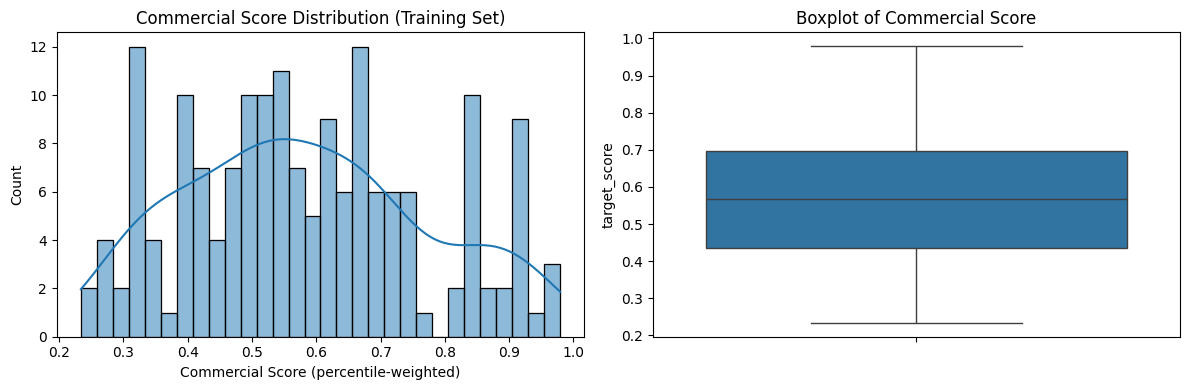

In [22]:
# --- 2. Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Commercial Score Distribution (Training Set)')
axes[0].set_xlabel('Commercial Score (percentile-weighted)')
sns.boxplot(y=y_train, ax=axes[1])
axes[1].set_title('Boxplot of Commercial Score')
plt.tight_layout()
plt.show()


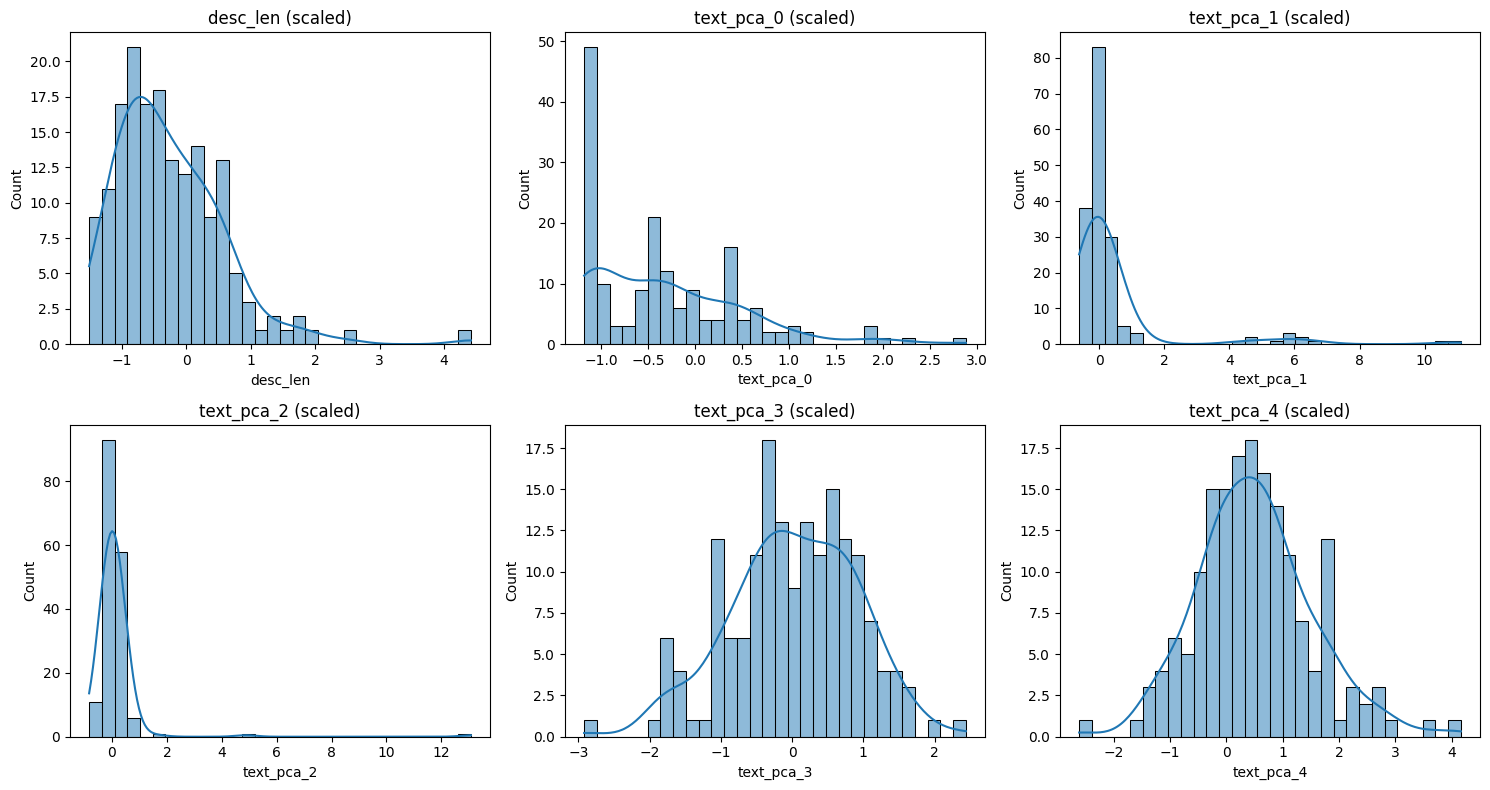

In [23]:
# --- 3. Feature Distributions (Top numeric features) ---
num_cols = ['desc_len'] + [c for c in X_train.columns if c.startswith('text_pca_')][:5]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(X_train[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{col} (scaled)')
plt.tight_layout()
plt.show()


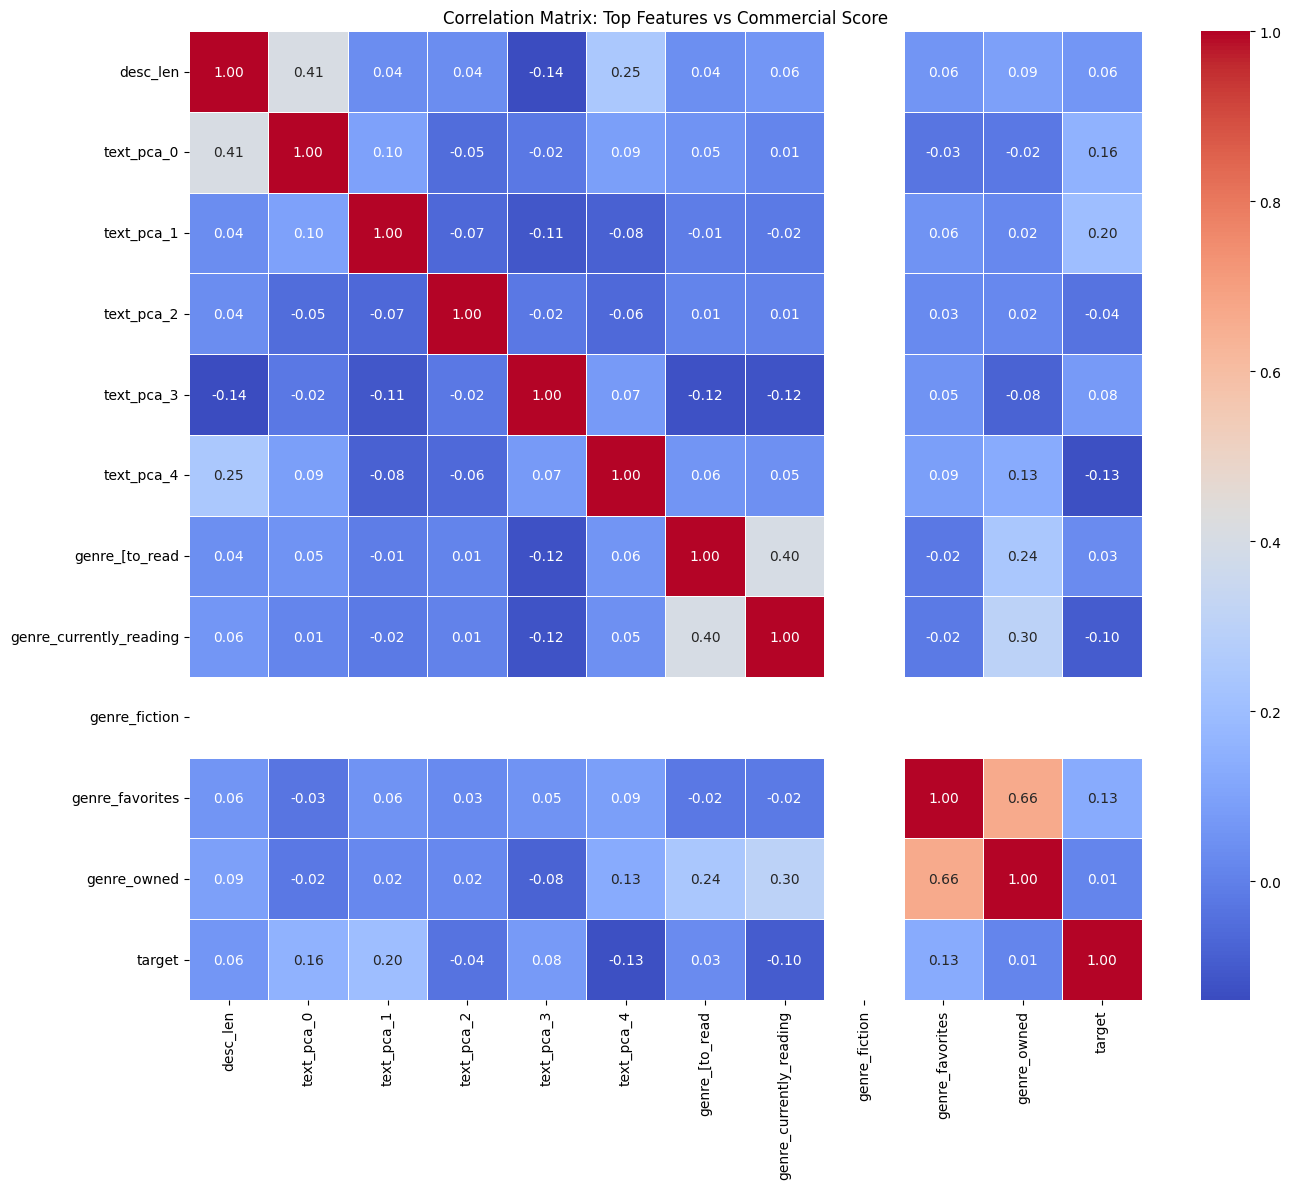

In [24]:
# --- 4. Correlation Heatmap (Top features vs Target) ---
# Select top 15 features by variance or just a subset to keep heatmap readable
top_features = ['desc_len'] + [c for c in X_train.columns if c.startswith('text_pca_')][:5] + \
               [c for c in X_train.columns if c.startswith('genre_')][:5]
corr_data = X_train[top_features].copy()
corr_data['target'] = y_train
plt.figure(figsize=(14, 12))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Top Features vs Commercial Score')
plt.tight_layout()
plt.show()

IndexError: index 3 is out of bounds for axis 0 with size 3

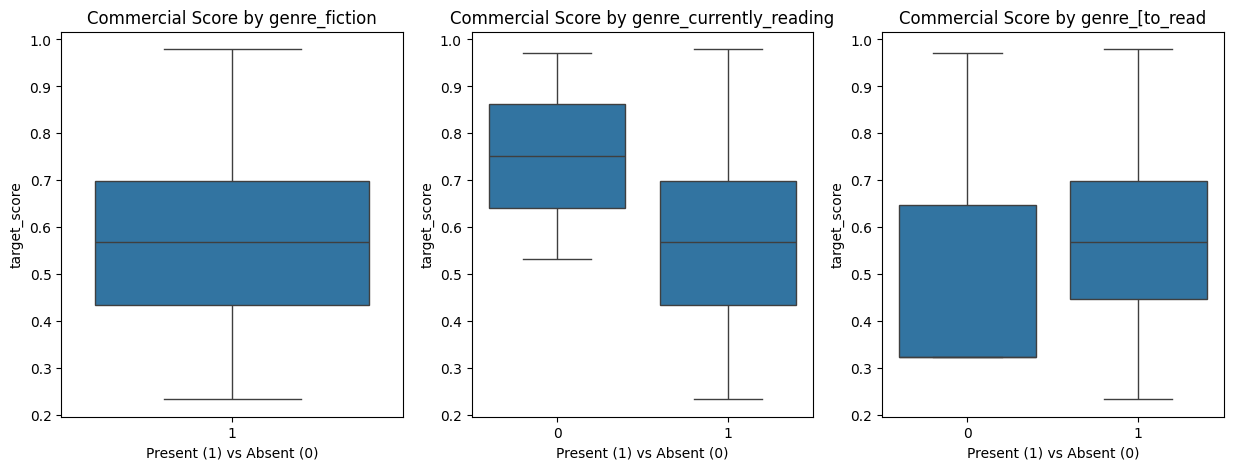

In [25]:

genre_cols = [c for c in X_train.columns if c.startswith('genre_')]
if genre_cols:
    # Get top 10 genres by frequency
    genre_counts = X_train[genre_cols].sum().sort_values(ascending=False)
    top3_genres = genre_counts.head(10).index.tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, genre in enumerate(top3_genres):
        sns.boxplot(x=X_train[genre], y=y_train, ax=axes[i])
        axes[i].set_title(f'Commercial Score by {genre}')
        axes[i].set_xlabel('Present (1) vs Absent (0)')
    plt.tight_layout()
    plt.show()

In [ ]:

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train['desc_len'], y=y_train, alpha=0.4)
plt.xlabel('Description Length (scaled)')
plt.ylabel('Commercial Score')
plt.title('Description Length vs Commercial Potential')
plt.show()

In [ ]:

print("\n" + "="*50)
print("BASELINE MODEL PERFORMANCE")
print("="*50)

# Split training data further for validation (80/20)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_tr, y_tr)

y_pred_train = model.predict(X_tr)
y_pred_val = model.predict(X_val)

train_r2 = r2_score(y_tr, y_pred_train)
val_r2 = r2_score(y_val, y_pred_val)
train_rmse = np.sqrt(mean_squared_error(y_tr, y_pred_train))  
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))      

print(f"Training R²: {train_r2:.4f}")
print(f"Validation R²: {val_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

In [ ]:
#Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10
top_feature_names = [X_train.columns[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.barh(top_feature_names, top_importances)
plt.xlabel('Feature Importance')
plt.title('Top 10 Features Driving Commercial Score (Random Forest)')
plt.tight_layout()
plt.show()


In [ ]:

# Interpret the results 
print("\n" + "="*50)
print("KEY INSIGHTS (Checklist Item 7)")
print("="*50)
print(f"1. Baseline R² on validation: {val_r2:.3f} — {'✅ Good signal' if val_r2 > 0.2 else '⚠️ Weak signal, consider more features'}") #used LLM to decide good target r2 here can discuss in class I think very low r2 makes sense
print(f"2. Top feature: '{top_feature_names[-1]}' with importance {top_importances[-1]:.3f}")
print("3. Check the boxplots above to see which genres have higher commercial scores.")
print("4. Description length correlation with target: {:.3f}".format(corr_data['desc_len'].corr(corr_data['target'])))

In [ ]:
# Check that vectorizer and pca exist
try:
    feature_names = vectorizer.get_feature_names_out()
    components = pca.components_
except NameError:
    raise NameError("Vectorizer or PCA not found. Please rerun Cell 5.")

In [ ]:
# Get PCA columns and their importance from the trained model
pca_cols = [c for c in X_train.columns if c.startswith('text_pca_')]
pca_indices = [int(c.split('_')[-1]) for c in pca_cols]
importances = model.feature_importances_
feat_imp = dict(zip(X_train.columns, importances))
pca_importance = {i: feat_imp.get(f'text_pca_{i}', 0) for i in pca_indices}
top_pcas = sorted(pca_importance.items(), key=lambda x: x[1], reverse=True)[:3] #takes top3

print("Top 3 PCA components by model importance:")
for idx, imp in top_pcas:
    print(f"  text_pca_{idx}: {imp:.4f}")

# Function that takes components as an argument
def show_pca_words(component_idx, components, feature_names, top_n=15):
    loadings = components[component_idx]
    sorted_idx = np.argsort(loadings)
    
    pos_idx = sorted_idx[-top_n:][::-1]
    neg_idx = sorted_idx[:top_n]
    
    pos_words = [(feature_names[i], loadings[i]) for i in pos_idx]
    neg_words = [(feature_names[i], loadings[i]) for i in neg_idx]
    
    print(f"\ntext_pca_{component_idx}:")
    print("  Positive words:", ', '.join([w for w, _ in pos_words[:5]]))
    print("  Negative words:", ', '.join([w for w, _ in neg_words[:5]]))
    
    df_pos = pd.DataFrame(pos_words, columns=['Word', 'Loading'])
    df_neg = pd.DataFrame(neg_words, columns=['Word', 'Loading'])
    df_plot = pd.concat([df_pos, df_neg])
    df_plot['Color'] = ['green'] * len(pos_words) + ['red'] * len(neg_words)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(df_plot['Word'], df_plot['Loading'], color=df_plot['Color'])
    ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Loading')
    ax.set_title(f'text_pca_{component_idx}: Top Words (Positive = green, Negative = red)')
    plt.tight_layout()
    plt.show()

# Analyze top 3 components 
for idx, _ in top_pcas:
    show_pca_words(idx, components, feature_names)

# Compute correlation of each PCA component with target
corr_data = X_train[pca_cols].copy()
corr_data['target'] = y_train
correlations = {int(c.split('_')[-1]): corr_data[c].corr(corr_data['target']) for c in pca_cols}
top_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)[:5]

print("\nPCA components with strongest linear correlation to target:")
for idx, corr in top_corr:
    print(f"  text_pca_{idx}: {corr:.4f}")